In [1]:
# you may want to import some modules here
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, precision_score, root_mean_squared_error
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector

spf_data = pd.read_csv("StudentPerformanceFactors.csv")
cleaned_spf_data = spf_data.copy().dropna()

---

### Linear Regression using Forward Selection and K-Fold CV

#### Predict exam scores with only quantitative features

Starting Forward Selection (This may take a moment)...

Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
Number of Selected Features: 5
Total Features: 6

Average R-squared: 0.594 (+/- 0.056)
Average RMSE: 2.488 (+/- 0.208)


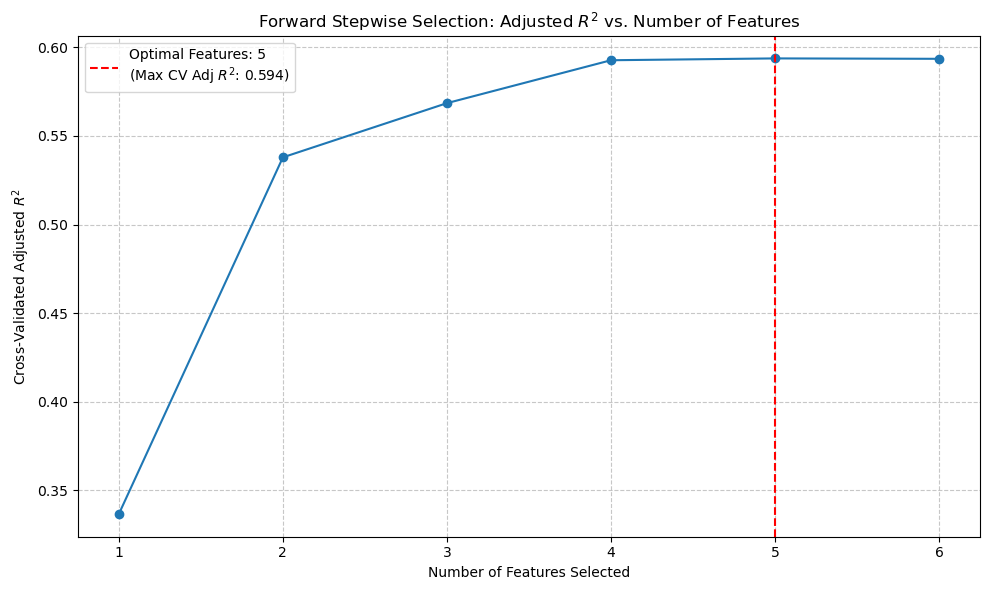

In [2]:
int_c_spf = cleaned_spf_data.select_dtypes(include=['int64', 'float64'])

X = int_c_spf.drop(columns=['Exam_Score'])
y = int_c_spf['Exam_Score']

n_samples = X.shape[0]
total_features = X.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X.columns)
adj_r2_scores = []

lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# Iteratively select features
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    # Test all remaining features to see which one improves the model the most
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X[test_features]
        
        # Calculate 5-fold CV R-squared for this subset
        score = cross_val_score(lin_reg, X_subset, y, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    # Lock in the best feature for this round
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    # Calculate Adjusted R-squared using the formula: 1 - (1 - R2) * (n - 1) / (n - p - 1)
    p = i  # Number of features currently selected
    adj_r2 = 1 - (1 - best_r2) * (n_samples - 1) / (n_samples - p - 1)
    adj_r2_scores.append(adj_r2)

max_adj_r2 = max(adj_r2_scores)
optimal_features = adj_r2_scores.index(max_adj_r2) + 1

# Extract the selected features
selected_feature_names = selected_features[:optimal_features]
print(f"\nSelected Features: {list(selected_feature_names)}")
print(f"Number of Selected Features: {len(selected_feature_names)}")
print(f"Total Features: {total_features}\n")

# Transform our dataset to ONLY include the selected features
X_selected = X[selected_feature_names]

# Run K-Fold Cross Validation on the final model using only the selected features
cv_r2_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print Results
print(f"Average R-squared: {cv_r2_scores.mean():.3f} (+/- {cv_r2_scores.std():.3f})")
print(f"Average RMSE: {cv_rmse_scores.mean():.3f} (+/- {cv_rmse_scores.std():.3f})")

# Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Highlight the optimal number of features
ax.axvline(x=optimal_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()

---

#### Predict exam scores with only qualitative features

Starting Forward Selection (This may take a moment)...

Selected Features: ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Parental_Education_Level_Postgraduate', 'Family_Income_Low', 'Learning_Disabilities_Yes', 'Distance_from_Home_Near', 'Motivation_Level_Low', 'Peer_Influence_Positive', 'Extracurricular_Activities_Yes', 'Peer_Influence_Neutral', 'Parental_Education_Level_High School', 'Internet_Access_Yes', 'Family_Income_Medium', 'Motivation_Level_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Distance_from_Home_Moderate']
Number of Selected Features: 19
Total Features: 21

Average R-squared: 0.114 (+/- 0.021)
Average RMSE: 3.683 (+/- 0.090)


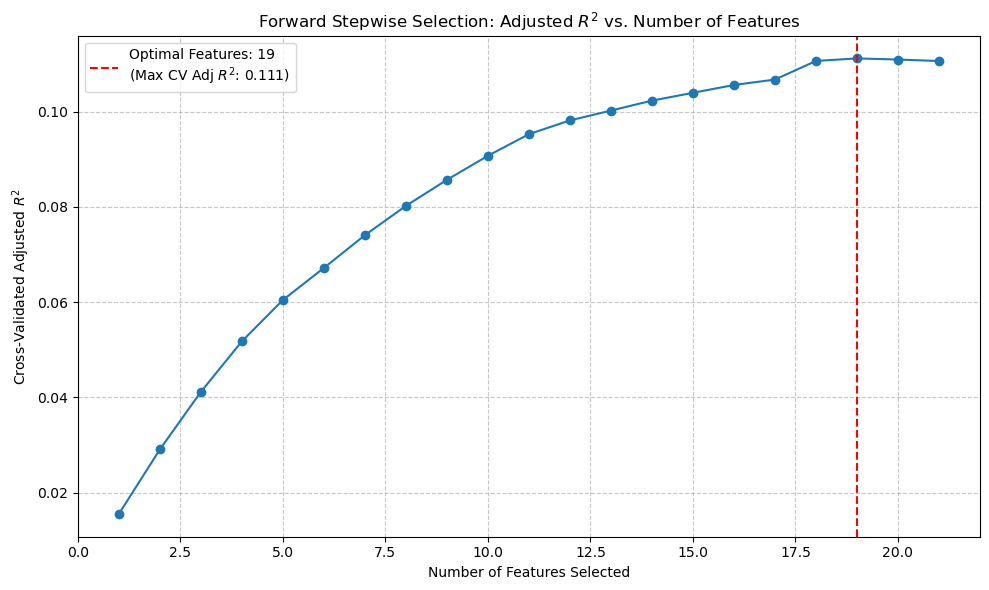

In [3]:
int_c_spf2 = cleaned_spf_data.select_dtypes(include=['object'])

X = pd.get_dummies(int_c_spf2, drop_first=True)
y = cleaned_spf_data['Exam_Score']

n_samples = X.shape[0]
total_features = X.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X.columns)
adj_r2_scores = []

lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# Iteratively select features
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    # Test all remaining features to see which one improves the model the most
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X[test_features]
        
        # Calculate 5-fold CV R-squared for this subset
        score = cross_val_score(lin_reg, X_subset, y, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    # Lock in the best feature for this round
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    # Calculate Adjusted R-squared using the formula: 1 - (1 - R2) * (n - 1) / (n - p - 1)
    p = i  # Number of features currently selected
    adj_r2 = 1 - (1 - best_r2) * (n_samples - 1) / (n_samples - p - 1)
    adj_r2_scores.append(adj_r2)

max_adj_r2 = max(adj_r2_scores)
optimal_features = adj_r2_scores.index(max_adj_r2) + 1

# Extract the selected features
selected_feature_names = selected_features[:optimal_features]
print(f"\nSelected Features: {list(selected_feature_names)}")
print(f"Number of Selected Features: {len(selected_feature_names)}")
print(f"Total Features: {total_features}\n")

# Transform our dataset to ONLY include the selected features
X_selected = X[selected_feature_names]

# Run K-Fold Cross Validation on the final model using only the selected features
cv_r2_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print Results
print(f"Average R-squared: {cv_r2_scores.mean():.3f} (+/- {cv_r2_scores.std():.3f})")
print(f"Average RMSE: {cv_rmse_scores.mean():.3f} (+/- {cv_rmse_scores.std():.3f})")

# Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Highlight the optimal number of features
ax.axvline(x=optimal_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()

---

#### Predict exam scores with every other feature

Starting Forward Selection (This may take a moment)...

Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Family_Income_Low', 'Peer_Influence_Positive', 'Parental_Education_Level_High School', 'Motivation_Level_Low', 'Distance_from_Home_Near', 'Extracurricular_Activities_Yes', 'Learning_Disabilities_Yes', 'Internet_Access_Yes', 'Motivation_Level_Medium', 'Family_Income_Medium', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Peer_Influence_Neutral', 'Physical_Activity', 'Parental_Education_Level_Postgraduate', 'Distance_from_Home_Moderate']
Number of Selected Features: 24
Total Features: 27

Average R-squared: 0.721 (+/- 0.069)
Average RMSE: 2.053 (+/- 0.295)


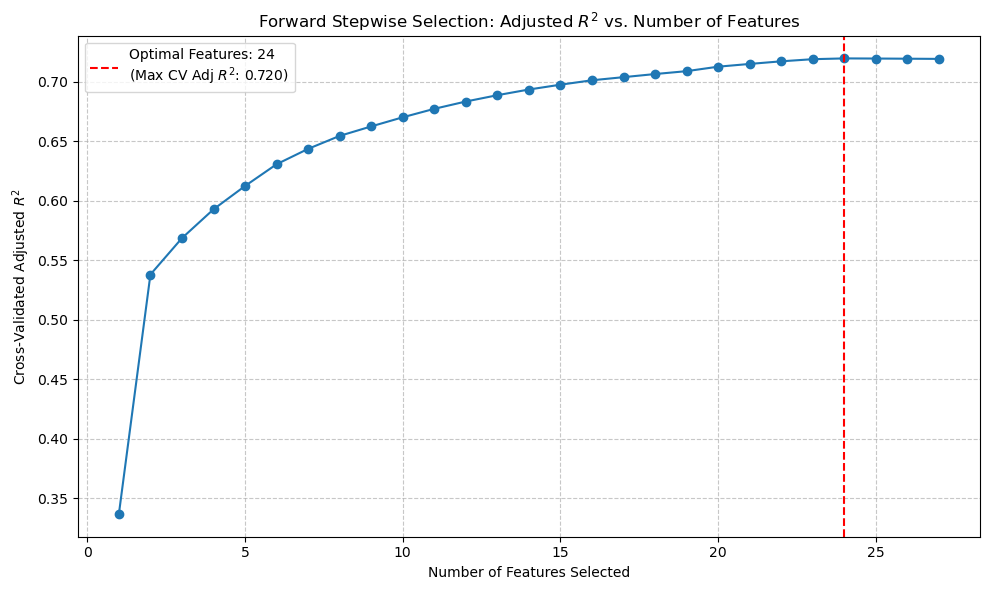

In [4]:
# Load and prepare data
X = cleaned_spf_data.drop(columns=["Exam_Score"])
y = cleaned_spf_data["Exam_Score"]
X_encoded = pd.get_dummies(X, drop_first=True)

n_samples = X_encoded.shape[0]
total_features = X_encoded.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X_encoded.columns)
adj_r2_scores = []

lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# Iteratively select features
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    # Test all remaining features to see which one improves the model the most
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X_encoded[test_features]
        
        # Calculate 5-fold CV R-squared for this subset
        score = cross_val_score(lin_reg, X_subset, y, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    # Lock in the best feature for this round
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    # Calculate Adjusted R-squared using the formula: 1 - (1 - R2) * (n - 1) / (n - p - 1)
    p = i  # Number of features currently selected
    adj_r2 = 1 - (1 - best_r2) * (n_samples - 1) / (n_samples - p - 1)
    adj_r2_scores.append(adj_r2)

max_adj_r2 = max(adj_r2_scores)
optimal_features = adj_r2_scores.index(max_adj_r2) + 1

# Extract the selected features
selected_feature_names = selected_features[:optimal_features]
print(f"\nSelected Features: {list(selected_feature_names)}")
print(f"Number of Selected Features: {len(selected_feature_names)}")
print(f"Total Features: {total_features}\n")

# Transform our dataset to ONLY include the selected features
X_selected = X_encoded[selected_feature_names]

# Run K-Fold Cross Validation on the final model using only the selected features
cv_r2_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(lin_reg, X_selected, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print Results
print(f"Average R-squared: {cv_r2_scores.mean():.3f} (+/- {cv_r2_scores.std():.3f})")
print(f"Average RMSE: {cv_rmse_scores.mean():.3f} (+/- {cv_rmse_scores.std():.3f})")

# Create the Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Highlight the optimal number of features
ax.axvline(x=optimal_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()

---

### Linear regression with forward selection and train-test split

#### Predict exam scores with only quantitative features

Starting Forward Selection (This may take a moment)...

Number of Selected Features: 5 (Out of 6)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Test R-squared: 0.623
Test Adjusted R-squared: 0.622
Test RMSE: 2.384


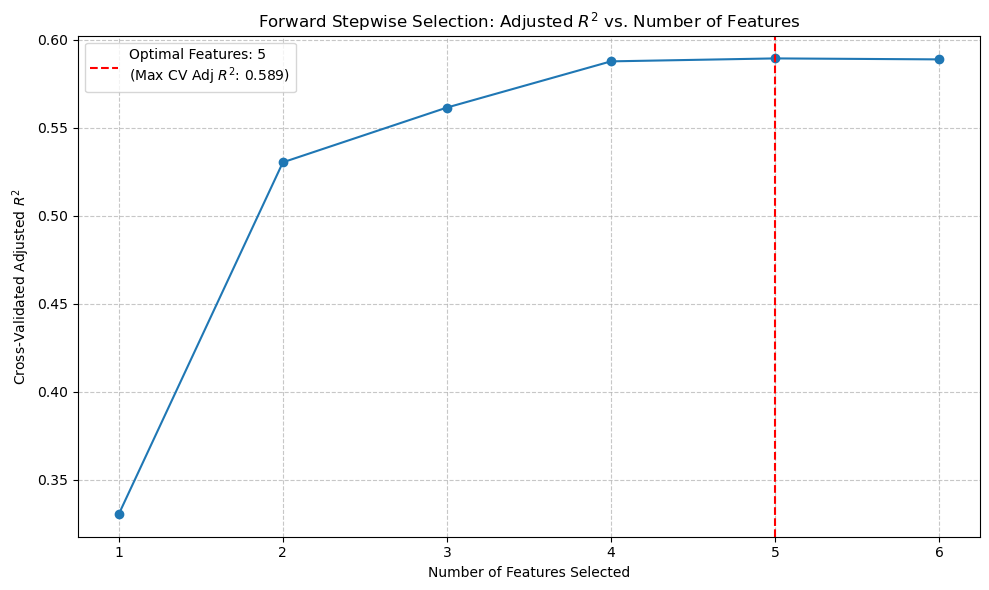

In [5]:
# 1. Load and prep data
X = cleaned_spf_data.select_dtypes(include=['int64', 'float64']).drop(columns=["Exam_Score"])
y = cleaned_spf_data["Exam_Score"]

# 2. Train-Test Split BEFORE feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

n_samples_train = X_train.shape[0]
total_features = X_train.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X_train.columns)
adj_r2_scores = []
lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# 3. Iteratively select features on TRAINING data
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X_train[test_features]
        
        score = cross_val_score(lin_reg, X_subset, y_train, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    p = i  
    adj_r2 = 1 - (1 - best_r2) * (n_samples_train - 1) / (n_samples_train - p - 1)
    adj_r2_scores.append(adj_r2)

# Find the peak of the curve
max_adj_r2 = max(adj_r2_scores)
optimal_num_features = adj_r2_scores.index(max_adj_r2) + 1

# 4. Grab the absolute best features (No need for SFS!)
best_feature_names = selected_features[:optimal_num_features]

print(f"\nNumber of Selected Features: {optimal_num_features} (Out of {total_features})")
print(f"Selected Features: {best_feature_names}\n")

# 5. Transform Train and Test sets manually
X_train_selected = X_train[best_feature_names]
X_test_selected = X_test[best_feature_names]

# 6. Train final model & Predict
lin_reg.fit(X_train_selected, y_train)
y_pred = lin_reg.predict(X_test_selected)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Correctly use the TEST set size for the test Adjusted R2
n_samples_test = X_test.shape[0]
final_adj_r2 = 1 - (1 - r2) * (n_samples_test - 1) / (n_samples_test - optimal_num_features - 1)

print(f"Test R-squared: {r2:.3f}")
print(f"Test Adjusted R-squared: {final_adj_r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

# 8. Plot the Cross-Validation Training Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Fixed the label to show the correct max_adj_r2
ax.axvline(x=optimal_num_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_num_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

---

#### Predict exam scores with only qualitative features

Starting Forward Selection (This may take a moment)...

Number of Selected Features: 20 (Out of 21)
Selected Features: ['Access_to_Resources_Low', 'Parental_Involvement_Low', 'Access_to_Resources_Medium', 'Parental_Involvement_Medium', 'Parental_Education_Level_Postgraduate', 'Learning_Disabilities_Yes', 'Family_Income_Low', 'Distance_from_Home_Near', 'Motivation_Level_Low', 'Peer_Influence_Positive', 'Extracurricular_Activities_Yes', 'Motivation_Level_Medium', 'Internet_Access_Yes', 'Peer_Influence_Neutral', 'Parental_Education_Level_High School', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Distance_from_Home_Moderate', 'Family_Income_Medium', 'School_Type_Public']

Test R-squared: 0.098
Test Adjusted R-squared: 0.083
Test RMSE: 3.689


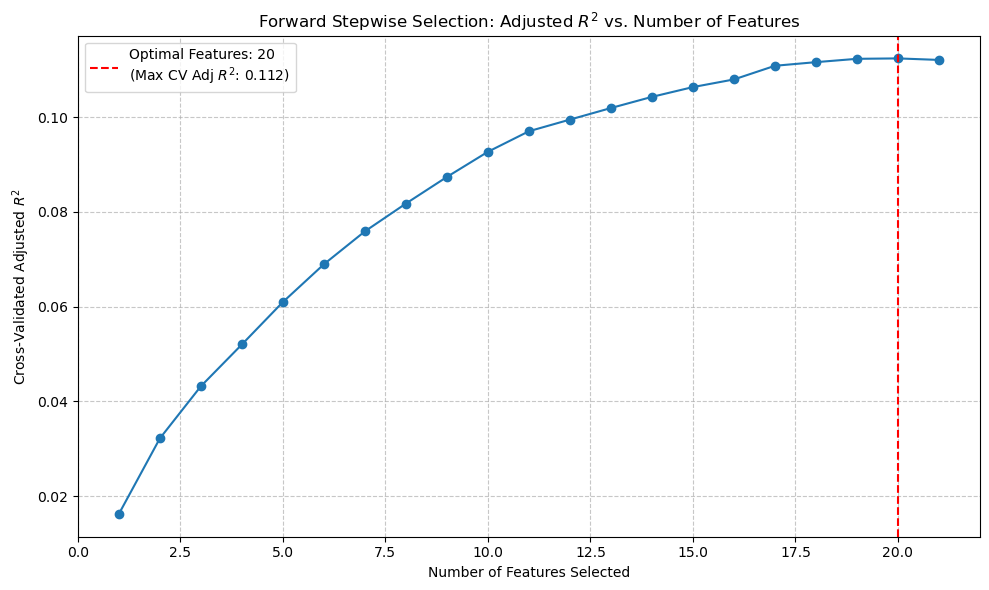

In [6]:
# 1. Load and prep data
X = cleaned_spf_data.select_dtypes(include=['object'])
y = cleaned_spf_data["Exam_Score"]
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split BEFORE feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=12
)

n_samples_train = X_train.shape[0]
total_features = X_train.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X_train.columns)
adj_r2_scores = []
lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# 3. Iteratively select features on TRAINING data
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X_train[test_features]
        
        score = cross_val_score(lin_reg, X_subset, y_train, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    p = i  
    adj_r2 = 1 - (1 - best_r2) * (n_samples_train - 1) / (n_samples_train - p - 1)
    adj_r2_scores.append(adj_r2)

# Find the peak of the curve
max_adj_r2 = max(adj_r2_scores)
optimal_num_features = adj_r2_scores.index(max_adj_r2) + 1

# 4. Grab the absolute best features (No need for SFS!)
best_feature_names = selected_features[:optimal_num_features]

print(f"\nNumber of Selected Features: {optimal_num_features} (Out of {total_features})")
print(f"Selected Features: {best_feature_names}\n")

# 5. Transform Train and Test sets manually
X_train_selected = X_train[best_feature_names]
X_test_selected = X_test[best_feature_names]

# 6. Train final model & Predict
lin_reg.fit(X_train_selected, y_train)
y_pred = lin_reg.predict(X_test_selected)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Correctly use the TEST set size for the test Adjusted R2
n_samples_test = X_test.shape[0]
final_adj_r2 = 1 - (1 - r2) * (n_samples_test - 1) / (n_samples_test - optimal_num_features - 1)

print(f"Test R-squared: {r2:.3f}")
print(f"Test Adjusted R-squared: {final_adj_r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

# 8. Plot the Cross-Validation Training Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Fixed the label to show the correct max_adj_r2
ax.axvline(x=optimal_num_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_num_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

---

#### Predict exam scores with every other feature

Starting Forward Selection (This may take a moment)...

Number of Selected Features: 24 (Out of 27)
Selected Features: ['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions', 'Access_to_Resources_Low', 'Parental_Involvement_Low', 'Parental_Involvement_Medium', 'Access_to_Resources_Medium', 'Family_Income_Low', 'Peer_Influence_Positive', 'Parental_Education_Level_High School', 'Motivation_Level_Low', 'Distance_from_Home_Near', 'Extracurricular_Activities_Yes', 'Learning_Disabilities_Yes', 'Internet_Access_Yes', 'Teacher_Quality_Low', 'Teacher_Quality_Medium', 'Family_Income_Medium', 'Physical_Activity', 'Motivation_Level_Medium', 'Parental_Education_Level_Postgraduate', 'Peer_Influence_Neutral', 'Distance_from_Home_Moderate']

Test R-squared: 0.742
Test Adjusted R-squared: 0.737
Test RMSE: 1.972


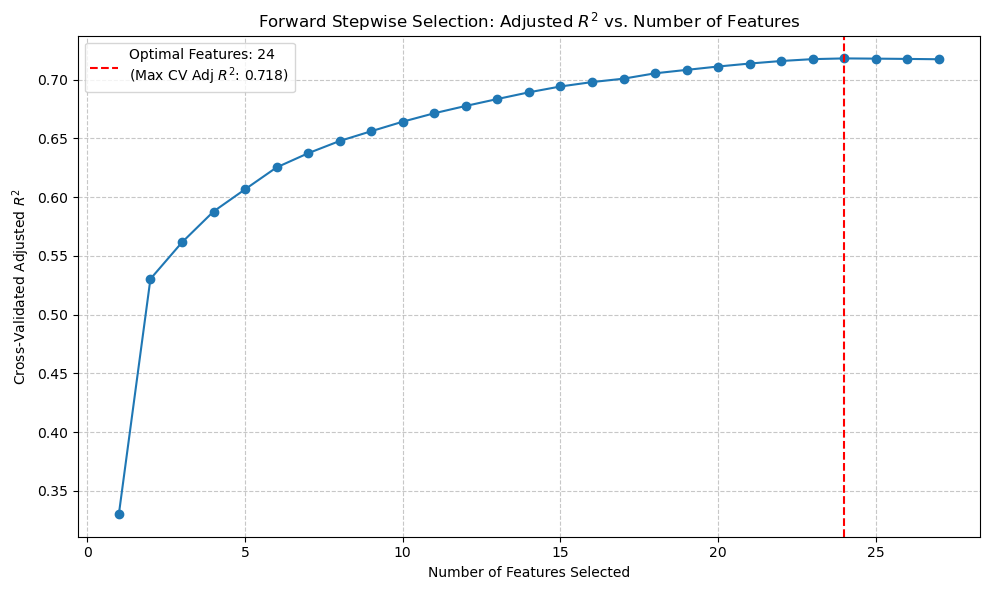

In [7]:
# 1. Load and prep data
X = cleaned_spf_data.drop(columns=["Exam_Score"])
y = cleaned_spf_data["Exam_Score"]
X_encoded = pd.get_dummies(X, drop_first=True)

# 2. Train-Test Split BEFORE feature selection
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=12
)

n_samples_train = X_train.shape[0]
total_features = X_train.shape[1]

# Variables to keep track of the selection process
selected_features = []
remaining_features = list(X_train.columns)
adj_r2_scores = []
lin_reg = LinearRegression()

print("Starting Forward Selection (This may take a moment)...")

# 3. Iteratively select features on TRAINING data
for i in range(1, total_features + 1):
    best_r2 = -np.inf
    best_feature = None
    
    for feature in remaining_features:
        test_features = selected_features + [feature]
        X_subset = X_train[test_features]
        
        score = cross_val_score(lin_reg, X_subset, y_train, cv=5, scoring='r2').mean()
        
        if score > best_r2:
            best_r2 = score
            best_feature = feature
            
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)
    
    p = i  
    adj_r2 = 1 - (1 - best_r2) * (n_samples_train - 1) / (n_samples_train - p - 1)
    adj_r2_scores.append(adj_r2)

# Find the peak of the curve
max_adj_r2 = max(adj_r2_scores)
optimal_num_features = adj_r2_scores.index(max_adj_r2) + 1

# 4. Grab the absolute best features (No need for SFS!)
best_feature_names = selected_features[:optimal_num_features]

print(f"\nNumber of Selected Features: {optimal_num_features} (Out of {total_features})")
print(f"Selected Features: {best_feature_names}\n")

# 5. Transform Train and Test sets manually
X_train_selected = X_train[best_feature_names]
X_test_selected = X_test[best_feature_names]

# 6. Train final model & Predict
lin_reg.fit(X_train_selected, y_train)
y_pred = lin_reg.predict(X_test_selected)

# 7. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

# Correctly use the TEST set size for the test Adjusted R2
n_samples_test = X_test.shape[0]
final_adj_r2 = 1 - (1 - r2) * (n_samples_test - 1) / (n_samples_test - optimal_num_features - 1)

print(f"Test R-squared: {r2:.3f}")
print(f"Test Adjusted R-squared: {final_adj_r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

# 8. Plot the Cross-Validation Training Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(1, total_features + 1), adj_r2_scores, marker='o', linestyle='-', color='#1f77b4')

ax.set_title('Forward Stepwise Selection: Adjusted $R^2$ vs. Number of Features')
ax.set_xlabel('Number of Features Selected')
ax.set_ylabel('Cross-Validated Adjusted $R^2$')
ax.grid(True, linestyle='--', alpha=0.7)

# Fixed the label to show the correct max_adj_r2
ax.axvline(x=optimal_num_features, color='red', linestyle='--', 
           label=f'Optimal Features: {optimal_num_features}\n(Max CV Adj $R^2$: {max_adj_r2:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

---

### Pruned Random Forest Regressors using train-test split on data

#### Predict exam scores with only quantitative features

In [8]:
# Create data set of predictors and column of exam scores
int_c_spf = cleaned_spf_data.copy().select_dtypes(include=['int64','float64'])
X_tree = int_c_spf.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_tree, y_tree, test_size=0.2, random_state=12
)

# 3. Create Model with n_jobs=-1 to use ALL computer cores
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# 4. Grid Search (Reduced to cv=5 to save time)
param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
grid_search = GridSearchCV(
    tree_reg_model, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Run CV folds in parallel
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_pruned_rf = grid_search.best_estimator_
print(f"Best alpha: {grid_search.best_params_['ccp_alpha']:.4f}")

# 5. Evaluate ONCE on the held-out test set (Instant!)
y_pred = best_pruned_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("\n--- Test Set Results ---")
print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

Starting Grid Search...
Best alpha: 0.0056

--- Test Set Results ---
R-squared: 0.525
RMSE: 2.676


---

#### Predict exam scores with only qualitative features

In [9]:
# Create data set of predictors and column of exam scores
X_tree = cleaned_spf_data.copy().select_dtypes(include=['object'])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Convert any columns which contain string objects to integers
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_tree_encoded, y_tree, test_size=0.2, random_state=12
)

# 3. Create Model with n_jobs=-1 to use ALL computer cores
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# 4. Grid Search (Reduced to cv=5 to save time)
param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
grid_search = GridSearchCV(
    tree_reg_model, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Run CV folds in parallel
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_pruned_rf = grid_search.best_estimator_
print(f"Best alpha: {grid_search.best_params_['ccp_alpha']:.4f}")

# 5. Evaluate ONCE on the held-out test set (Instant!)
y_pred = best_pruned_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("\n--- Test Set Results ---")
print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

Starting Grid Search...
Best alpha: 0.0500

--- Test Set Results ---
R-squared: 0.055
RMSE: 3.776


---

#### Predict exam scores with every other feature

In [10]:
# 1. Prep Data
X_tree = cleaned_spf_data.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_tree_encoded, y_tree, test_size=0.2, random_state=12
)

# 3. Create Model with n_jobs=-1 to use ALL computer cores
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# 4. Grid Search (Reduced to cv=5 to save time)
param_grid = {'ccp_alpha': np.linspace(0, 0.05, 10)}
grid_search = GridSearchCV(
    tree_reg_model, 
    param_grid, 
    cv=5, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Run CV folds in parallel
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_pruned_rf = grid_search.best_estimator_
print(f"Best alpha: {grid_search.best_params_['ccp_alpha']:.4f}")

# 5. Evaluate ONCE on the held-out test set (Instant!)
y_pred = best_pruned_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("\n--- Test Set Results ---")
print(f"R-squared: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

Starting Grid Search...
Best alpha: 0.0000

--- Test Set Results ---
R-squared: 0.622
RMSE: 2.386


### Unpruned Random Forest Regressors using K-Fold CV on data

#### Predict exam scores with only quantitative features

In [11]:
# Create data set of predictors and column of exam scores
int_c_spf = cleaned_spf_data.copy().select_dtypes(include=['int64','float64'])
X_tree = int_c_spf.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [0.447 0.484 0.502 0.543 0.605]
Average R-squared: 0.516 (Standard Deviation: +/- 0.054)
Individual RMSE scores: [2.974 2.829 2.743 2.638 2.407]
Average RMSE: 2.718 (Standard Deviation: +/- 0.191)


---

#### Predict exam scores with only qualitative features

In [12]:
# Create data set of predictors and column of exam scores
X_tree = cleaned_spf_data.copy().select_dtypes(include=['object'])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Convert any columns which contain string objects to integers
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [-0.072 -0.053 -0.014 -0.042 -0.111]
Average R-squared: -0.058 (Standard Deviation: +/- 0.032)
Individual RMSE scores: [4.143 4.042 3.915 3.984 4.035]
Average RMSE: 4.024 (Standard Deviation: +/- 0.075)


---

#### Predict exam scores with every other feature

In [13]:
# Create data set of predictors and column of exam scores
X_tree = cleaned_spf_data.copy().drop(columns=["Exam_Score"])
y_tree = cleaned_spf_data["Exam_Score"].copy()

# Convert any columns which contain string objects to integers
X_tree_encoded = pd.get_dummies(X_tree, drop_first=True)

# Create the random forest regressor object
tree_reg_model = RandomForestRegressor(random_state=12, n_jobs=-1)

# Use k-fold cross validation to calculate R^2 and RMSE scores of different subsets
cv_r2_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='r2')
cv_neg_mse_scores = cross_val_score(tree_reg_model, X_tree_encoded, y_tree, cv=5, scoring='neg_mean_squared_error')
cv_rmse_scores = np.sqrt(-cv_neg_mse_scores)

# Print results
print(f"Individual R-squared scores: {cv_r2_scores.round(3)}")
print(f"Average R-squared: {round(cv_r2_scores.mean(),3)} (Standard Deviation: +/- {round(cv_r2_scores.std(),3)})")
print(f"Individual RMSE scores: {cv_rmse_scores.round(3)}")
print(f"Average RMSE: {round(cv_rmse_scores.mean(),3)} (Standard Deviation: +/- {round(cv_rmse_scores.std(),3)})")

Individual R-squared scores: [0.528 0.603 0.587 0.621 0.7  ]
Average R-squared: 0.608 (Standard Deviation: +/- 0.056)
Individual RMSE scores: [2.749 2.482 2.498 2.403 2.098]
Average RMSE: 2.446 (Standard Deviation: +/- 0.209)


---